# Coding Project 1: Linear Regression and Regularization

**Please write the names of all group members here:**




---

*Note:* The provided structure for the code below is only suggestive. You may structure your program differently, provided that your notebook is readable, reproducible, and answers all questions clearly.

A minimal `sklearn` workflow example is included before Question 3. It is intended to illustrate the use of `ColumnTransformer`, `Pipeline`, and `GridSearchCV`; it does **not** solve the project questions for you.

### Question 1 - Importing and Preparing the Data

(1460, 79) (1460,)


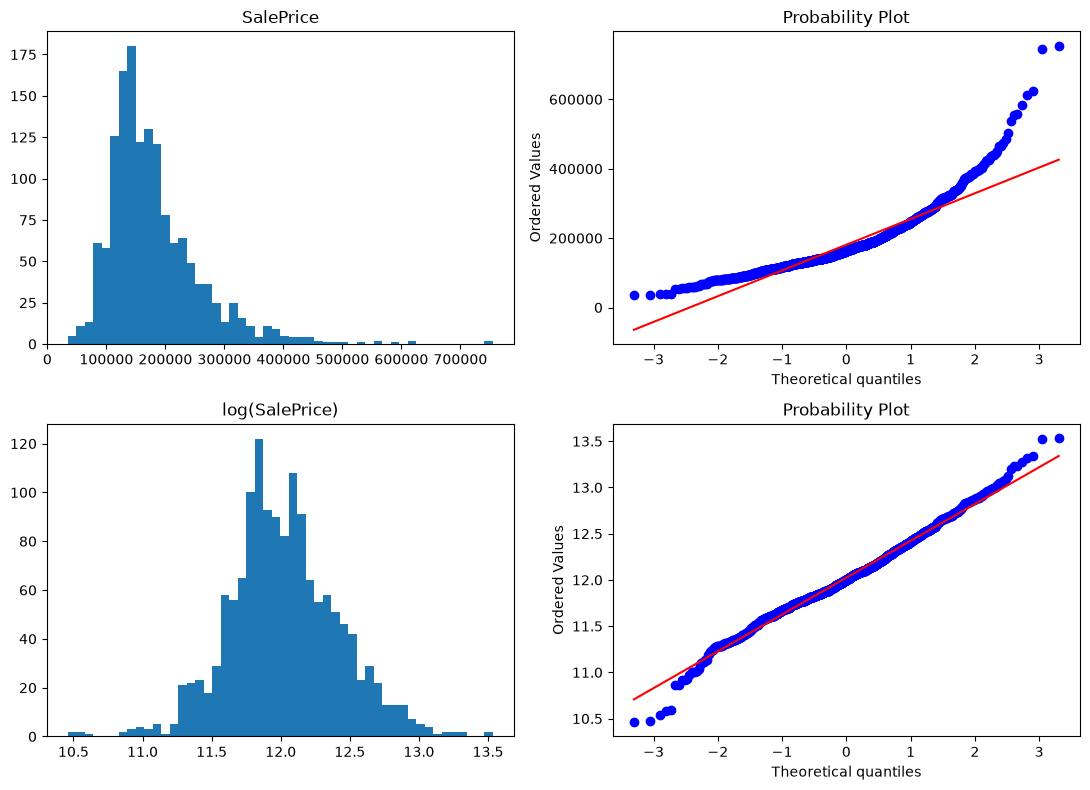

skew before: 1.880940746034036  after log: 0.1212103673013655
(1022, 79) (438, 79)
35 numerical features, 44 categorical features
train: (1022, 310)  test: (438, 310)
same columns: True
missing values: 0 0


In [7]:
# For Question 1, you may find the following packages useful:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split

# 1.a) Import Housing.csv as a pandas DataFrame.
# Separate the explanatory features X from the target y = SalePrice.
#
# Guidance:
# - Refer to data_description.txt to determine how variables should be interpreted.
# - The first column of the csv file is an index and should not be used as an explanatory variable.
# - Keep the original variable names so that later coefficient tables are easy to interpret.

df = pd.read_csv("Housing.csv", index_col=0)   # first column (Id) is only an index

# MSSubClass is stored as a number but it is a code for the type of dwelling -> categorical
# (this gives the 35 numerical and 44 categorical features of the project description)
df["MSSubClass"] = df["MSSubClass"].astype(str)

# print(df)

X = df.drop(columns="SalePrice")
y = df["SalePrice"]
print(X.shape, y.shape)

# 1.b) Graphically determine whether SalePrice is approximately Gaussian.
# If it is not, suggest and apply a suitable transformation.
# Explain why considering such a transformation can be important.
#
# Guidance:
# - Use suitable graphical diagnostics (for example, a histogram and/or Q-Q plot).
# - Keep track of the transformation you choose because later questions require metrics
#   both on the transformed scale and, after inverse transformation, on the original
#   SalePrice scale.

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
ax[0, 0].hist(y, bins=50)
ax[0, 0].set_title("SalePrice")
stats.probplot(y, dist="norm", plot=ax[0, 1])
ax[1, 0].hist(np.log(y), bins=50)
ax[1, 0].set_title("log(SalePrice)")
stats.probplot(np.log(y), dist="norm", plot=ax[1, 1])
plt.tight_layout()
plt.show()

print("skew before:", stats.skew(y), " after log:", stats.skew(np.log(y)))


# SalePrice is right skewed (long tail of expensive houses) and the QQ plot curves up
# in the upper tail -> not gaussian. After taking the log it is much more symmetric and
# the QQ plot is close to a straight line, so we use log(SalePrice) as target.
# This matters because linear regression works best with symmetric errors with constant
# variance, otherwise the few very expensive houses dominate the squared error.
y = np.log(y)



# 1.c) Split the data into training and test sets.
# Randomly assign 70% of the observations to the training set and 30% to the test set.
#
# IMPORTANT:
# - Save an UNPROCESSED copy of X_train and X_test before doing any imputation,
#   standardization, or one-hot encoding.
# - You will return to these raw splits in Question 3.b) to build a leakage-safe
#   cross-validation pipeline.
#
# Suggested naming:
# X_train_raw, X_test_raw, y_train, y_test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
print(X_train_raw.shape, X_test_raw.shape)



# 1.d) Prepare X_train and X_test using TRAINING-SET information only.
#
# Required steps:
# (i)   Numerical missing values: impute with the corresponding training-set mean.
# (ii)  Categorical missing values: impute with the most frequent category in the
#       corresponding training column.
# (iii) Treat 'NA' / 'None' as actual categorical levels where the data description
#       specifies that they are valid categories, rather than automatically treating
#       them as missing.
# (iv)  Standardize numerical features using training-set means and standard deviations,
#       and apply the same transformation, using these training-set statistics, to
#       the test set.
# (v)   One-hot encode the categorical variables.
# (vi)  Ensure that the test set contains the same encoded feature columns, in the
#       same order, as the training set.
#
# Hint:
# If pd.get_dummies is applied separately to the training and test sets, they may
# produce different dummy-variable columns because some categorical levels occur
# in only one of the two sets. The regression model must receive the same feature
# columns at training and prediction time. One possible way to align the encoded
# test columns to the training columns is:
#
# X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
#
# This creates any training dummy column missing from the test set and fills it
# with zero, while also matching the training-column order.
#
# Expected output / checks:
# - Report the final shapes of the prepared training and test feature matrices.
# - Verify that the encoded feature columns and their order are identical.
# - Do not use any test-set statistic to fit the preprocessing.




X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

# (iii) for these columns NA means "no alley", "no basement", "no garage"... (data_description.txt)
# pandas reads "NA" and "None" as missing, so we put them back as a real category
na_cols = ["Alley", "MasVnrType", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
           "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish", "GarageQual",
           "GarageCond", "PoolQC", "Fence", "MiscFeature"]
X_train[na_cols] = X_train[na_cols].fillna("None")
X_test[na_cols] = X_test[na_cols].fillna("None")

num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(exclude="number").columns

# (i) numerical: mean of the training set
means = X_train[num_cols].mean()
X_train[num_cols] = X_train[num_cols].fillna(means)
X_test[num_cols] = X_test[num_cols].fillna(means)

# (ii) categorical: most frequent category of the training set
modes = X_train[cat_cols].mode().iloc[0]
X_train[cat_cols] = X_train[cat_cols].fillna(modes)
X_test[cat_cols] = X_test[cat_cols].fillna(modes)

# (iv) z-score with training mean and std
mu = X_train[num_cols].mean()
sd = X_train[num_cols].std()
X_train[num_cols] = (X_train[num_cols] - mu) / sd
X_test[num_cols] = (X_test[num_cols] - mu) / sd

# (v) one hot encoding
X_train = pd.get_dummies(X_train, columns=cat_cols, dtype=float)
X_test = pd.get_dummies(X_test, columns=cat_cols, dtype=float)

# (vi) same columns in the same order as the training set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(len(num_cols), "numerical features,", len(cat_cols), "categorical features")
print("train:", X_train.shape, " test:", X_test.shape)
print("same columns:", list(X_train.columns) == list(X_test.columns))
print("missing values:", X_train.isna().sum().sum(), X_test.isna().sum().sum())


### Question 2 - Linear Regression on Numerical Features

intercept: 12.032638784447805
               coefficient
LotFrontage        -0.0044
LotArea             0.0236
OverallQual         0.1090
OverallCond         0.0508
YearBuilt           0.0919
YearRemodAdd        0.0229
MasVnrArea         -0.0035
BsmtFinSF1          0.0106
BsmtFinSF2          0.0038
BsmtUnfSF           0.0049
TotalBsmtSF         0.0171
1stFlrSF            0.0348
2ndFlrSF            0.0132
LowQualFinSF        0.0030
GrLivArea           0.0370
BsmtFullBath        0.0313
BsmtHalfBath        0.0064
FullBath            0.0259
HalfBath            0.0072
BedroomAbvGr        0.0073
KitchenAbvGr       -0.0259
TotRmsAbvGrd        0.0401
Fireplaces          0.0299
GarageYrBlt        -0.0152
GarageCars          0.0558
GarageArea          0.0082
WoodDeckSF          0.0222
OpenPorchSF         0.0049
EnclosedPorch       0.0185
3SsnPorch           0.0044
ScreenPorch         0.0204
PoolArea           -0.0207
MiscVal             0.0001
MoSold              0.0065
YrSold             -0.008

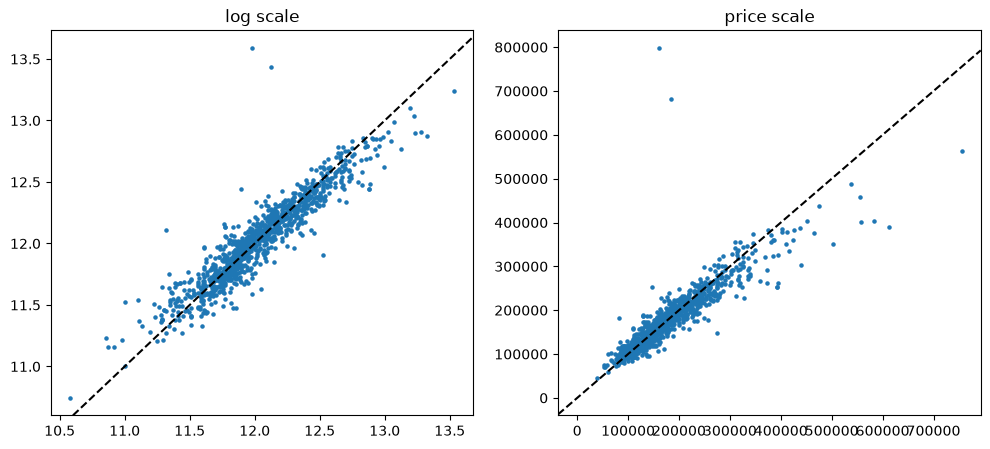

2.(i)
                 numpy  sklearn
intercept      12.0326  12.0326
LotFrontage    -0.0044  -0.0044
LotArea         0.0236   0.0236
OverallQual     0.1090   0.1090
OverallCond     0.0508   0.0508
YearBuilt       0.0919   0.0919
YearRemodAdd    0.0229   0.0229
MasVnrArea     -0.0035  -0.0035
BsmtFinSF1      0.2978   0.0106
BsmtFinSF2      0.1060   0.0038
BsmtUnfSF       0.2769   0.0049
TotalBsmtSF    -0.2608   0.0171
1stFlrSF       -0.1329   0.0348
2ndFlrSF       -0.1728   0.0132
LowQualFinSF   -0.0175   0.0030
GrLivArea       0.2634   0.0370
BsmtFullBath    0.0313   0.0313
BsmtHalfBath    0.0064   0.0064
FullBath        0.0259   0.0259
HalfBath        0.0072   0.0072
BedroomAbvGr    0.0073   0.0073
KitchenAbvGr   -0.0259  -0.0259
TotRmsAbvGrd    0.0401   0.0401
Fireplaces      0.0299   0.0299
GarageYrBlt    -0.0152  -0.0152
GarageCars      0.0558   0.0558
GarageArea      0.0082   0.0082
WoodDeckSF      0.0222   0.0222
OpenPorchSF     0.0049   0.0049
EnclosedPorch   0.0185   0.0185
3S

/tmp/ipykernel_392515/2834068654.py:105: RuntimeWarning: invalid value encountered in sqrt
  se = np.sqrt(sigma2 * np.diag(np.linalg.inv(A.T @ A)))         # Var(beta) = sigma2 (A^T A)^-1


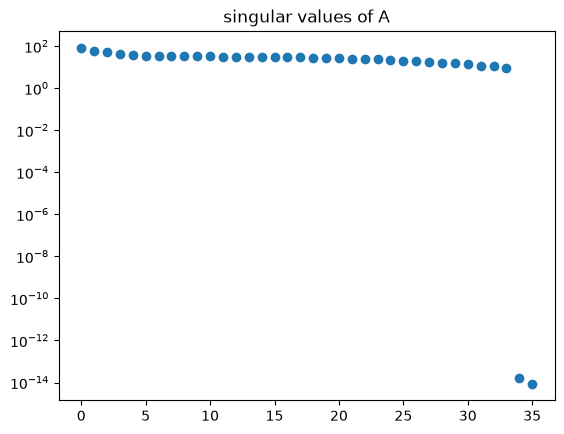

2.(v)
               coef inv     coef pinv       se inv       se pinv
intercept       12.0326  1.203260e+01       0.0046  4.700000e-03
LotFrontage     -0.0044 -4.400000e-03       0.0055  5.600000e-03
LotArea          0.0236  2.360000e-02       0.0052  5.300000e-03
OverallQual      0.1090  1.090000e-01       0.0082  8.300000e-03
OverallCond      0.0508  5.080000e-02       0.0060  6.100000e-03
YearBuilt        0.0919  9.180000e-02       0.0105  1.070000e-02
YearRemodAdd     0.0229  2.290000e-02       0.0072  7.300000e-03
MasVnrArea      -0.0035 -3.600000e-03       0.0056  5.700000e-03
BsmtFinSF1       0.2978 -4.503490e+10  106191.5220  1.499908e+11
BsmtFinSF2       0.1060 -1.602674e+10   37790.7701  5.337778e+10
BsmtUnfSF        0.2769 -4.263468e+10  100531.8418  1.419968e+11
TotalBsmtSF     -0.2608  4.356901e+10  102734.9717  1.451086e+11
1stFlrSF        -0.1329 -6.335734e+10          NaN  2.110145e+11
2ndFlrSF        -0.1728 -7.025734e+10          NaN  2.339953e+11
LowQualFinSF    -0.

/tmp/ipykernel_392515/2834068654.py:207: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols_sm = sm.OLS(y_A, A).fit()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# 2.a) Fit an OLS regression using ONLY the numerical predictors and sklearn.
# Include an intercept.
#
# Required output:
# - A table with each numerical feature and its estimated regression coefficient.
# - In-sample and out-of-sample MSE and R^2.
# - If y was transformed in Question 1.b), report MSE and R^2:
#     * on the transformed target scale; and
#     * on the original SalePrice scale after inverse-transforming predictions.
# - Briefly explain what the two scales tell you about model performance.

# OLS with only the numerical features (num_cols from 1.d)
ols = LinearRegression()   # fit_intercept=True by default
ols.fit(X_train[num_cols], y_train)

print("intercept:", ols.intercept_)
coefs = pd.DataFrame({"coefficient": ols.coef_}, index=num_cols)
print(coefs.round(4))

pred_train = ols.predict(X_train[num_cols])
pred_test = ols.predict(X_test[num_cols])

# metrics on the log scale and on the original price scale (np.exp to go back to prices)
results = pd.DataFrame({
    "MSE log": [mean_squared_error(y_train, pred_train), mean_squared_error(y_test, pred_test)],
    "R2 log": [r2_score(y_train, pred_train), r2_score(y_test, pred_test)],
    "MSE price": [mean_squared_error(np.exp(y_train), np.exp(pred_train)),
                  mean_squared_error(np.exp(y_test), np.exp(pred_test))],
    "R2 price": [r2_score(np.exp(y_train), np.exp(pred_train)),
                 r2_score(np.exp(y_test), np.exp(pred_test))],
}, index=["in-sample", "out-of-sample"])
print(results)



# predicted vs actual on the training set (dashed line = perfect prediction)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(y_train, pred_train, s=5)
ax[0].axline((12, 12), slope=1, color="k", ls="--")
ax[0].set_title("log scale")
ax[1].scatter(np.exp(y_train), np.exp(pred_train), s=5)
ax[1].axline((0, 0), slope=1, color="k", ls="--")
ax[1].set_title("price scale")
plt.show()


# MSE tells you how big the errors are. R² tells you how much better the model is than simply predicting the average.
# Log scale: this is the scale the model is fitted on. The errors are relative errors:
# R^2 is 0.86 in-sample and 0.87 out-of-sample, so the model does as well on new houses as on the
# training houses (no overfitting). MSE ~0.02 means a typical error of about sqrt(0.02) ~ 15% of the price.
# Price scale: the MSE is in dollars^2 and is bigger for expensive houses (in the right plot the points
# spread out when the price grows). The in-sample R^2 is lower here (0.77) because of the two houses
# far above the line in the right plot.


# 2.b) Reproduce and investigate OLS using matrix algebra on the TRAINING SET ONLY.
#
# Let A denote the design matrix containing the numerical predictors plus a column
# of ones for the intercept.
#
# (i) Compute the estimated coefficients using numpy.
#     Use a numerically stable linear-system solver such as np.linalg.solve(...)
#     whenever the system is numerically well behaved; do not explicitly form
#     a matrix inverse merely to solve the normal equations.
#
#     Expected output:
#     - Estimated intercept and feature coefficients.
#     - A comparison with the sklearn estimates from Question 2.a).

# We want to anaylse beta

# design matrix: column of ones (intercept) + the numerical features
print("2.(i)")
A = np.column_stack([np.ones(len(X_train)), X_train[num_cols].values])
y_A = y_train.values
n, p = A.shape

# normal equations (A^T A) beta = A^T y, solved without computing the inverse
beta = np.linalg.solve(A.T @ A, A.T @ y_A)

names = ["intercept"] + list(num_cols)
compare = pd.DataFrame({"numpy": beta, "sklearn": np.r_[ols.intercept_, ols.coef_]}, index=names)
print(compare.round(4))
print("mean difference:", np.abs(compare["numpy"] - compare["sklearn"]).mean())

# Most coefficients are the same as sklearn, but some of them are clearly different (see the table).
# We look at why in (iv).



# (ii) Compute the standard error of each estimated coefficient using numpy.
#
#      Expected output:
#      - A table containing coefficient estimates and their standard errors,
#        including the intercept.
#      - Clearly state which estimate corresponds to the intercept.

print("2.(ii)")
resid = y_A - A @ beta
sigma2 = resid @ resid / (n - p)                              # residual variance
se = np.sqrt(sigma2 * np.diag(np.linalg.inv(A.T @ A)))         # Var(beta) = sigma2 (A^T A)^-1

table = pd.DataFrame({"coef": beta, "std error": se}, index=names)   # first row = intercept
print(table.round(4))

# The first row is the intercept. Most standard errors are small, but for some variables they are
# huge or NaN -> something is wrong with A^T A .



# (iii) Using your matrix-algebra implementation, verify that the in-sample
#       MSE and R^2 agree with the corresponding results from Question 2.a),
#       up to numerical rounding.
print("2.(iii)")
fitted = A @ beta
mse = np.mean((y_A - fitted) ** 2)
r2 = 1 - np.sum((y_A - fitted) ** 2) / np.sum((y_A - y_A.mean()) ** 2)

print("numpy:   MSE =", mse, " R2 =", r2)
print("sklearn: MSE =", mean_squared_error(y_train, pred_train), " R2 =", r2_score(y_train, pred_train))

# Same MSE and R^2 as sklearn: the fit is the same, even if some coefficients are different.

# (iv) Inspect the numerical structure of A.
#
#      Required diagnostics:
#      - rank of A;
#      - singular values of A.
#
#      Guidance:
#      - np.linalg.matrix_rank(...) and np.linalg.svd(..., compute_uv=False)
#        may be useful.
#      - Comment on whether A is full column rank.
#      - Inspect the smallest singular values and discuss whether they suggest
#        potential numerical instability.
#      - Relate this evidence to the OLS calculations above.
print("2.(iv)")
print("rank of A:", np.linalg.matrix_rank(A), "/ columns:", p)
sv = np.linalg.svd(A, compute_uv=False)
print("largest singular values:", sv[:3])
print("smallest singular values:", sv[-3:])
print("condition number:", sv[0] / sv[-1])

plt.semilogy(sv, "o")
plt.title("singular values of A")
plt.show()

# A is not full column rank: rank 34 for 36 columns. In the plot, two singular values are almost 0
# (~1e-14) while all the others are above 9. So some columns are (almost exact) linear combinations
# of other columns.
# The condition number is huge (~1e16), so A^T A cannot really be inverted. This explains why some
# coefficients in (i) are different from sklearn and why some SEs in (ii) are huge or NaN,
# while the fit in (iii) is still fine.



# (v) Replace the usual inverse-based expression by the Moore-Penrose pseudoinverse.
#     Use np.linalg.pinv(...) with its default cutoff.
#
#     Required comparison:
#     - Do the coefficient estimates change?
#     - Does the residual variance estimate change?
#     - Do the standard errors change?
#     - Explain when the ordinary inverse-based and pseudoinverse-based results
#       should agree and when they may differ, using the diagnostics from (iv).

print("2.(v)")
A_pinv = np.linalg.pinv(A)                 # default cutoff
beta_pinv = A_pinv @ y_A
resid_pinv = y_A - A @ beta_pinv
sigma2_pinv = resid_pinv @ resid_pinv / (n - p)
se_pinv = np.sqrt(sigma2_pinv * np.diag(A_pinv @ A_pinv.T))   # pinv(A^T A) = pinv(A) pinv(A)^T

compare_pinv = pd.DataFrame({"coef inv": beta, "coef pinv": beta_pinv,
                             "se inv": se, "se pinv": se_pinv}, index=names)
print(compare_pinv.round(4))
print("sigma2 inv:", sigma2, " sigma2 pinv:", sigma2_pinv)
print("mean diff pinv vs sklearn:", np.abs(beta_pinv - np.r_[ols.intercept_, ols.coef_]).mean())

# same with a larger cutoff, to check where the problem comes from
beta_pinv2 = np.linalg.pinv(A, rcond=1e-10) @ y_A
print("pinv rcond=1e-10: MSE =", np.mean((y_A - A @ beta_pinv2) ** 2),
      " max diff vs sklearn:", np.abs(beta_pinv2 - np.r_[ols.intercept_, ols.coef_]).max())

# - Coefficients: the same for most variables, but the ones that were different in (i) become huge (~1e10).
# - Residual variance: it changes a little (0.0218 -> 0.0227).
# - Standard errors: the same for most variables, huge for these variables.
# Both methods give the same result when A has full column rank. Here A does not (see (iv)), so they
# differ. The default cutoff of pinv is too small for the two almost-zero singular values: with a
# bigger cutoff (rcond=1e-10, last line) the MSE is the same as OLS and we get the sklearn result again.


# (vi) Confirm your results with statsmodels OLS.
#
#      Required output:
#      - Coefficient estimates and standard errors from statsmodels.
#      - Compare them with your matrix-algebra results up to numerical rounding.
#      - If they differ, relate the discrepancy to the rank / numerical-stability
#        diagnostics above.


print("2.(vi)")
ols_sm = sm.OLS(y_A, A).fit()

compare_sm = pd.DataFrame({"coef pinv": beta_pinv, "coef statsmodels": ols_sm.params,
                           "se pinv": se_pinv, "se statsmodels": ols_sm.bse}, index=names)
print(compare_sm.round(4))
print("max coef difference:", np.abs(ols_sm.params - beta_pinv).max())
print("df_resid statsmodels:", ols_sm.df_resid, " n - p:", n - p)
print("max coef difference statsmodels vs sklearn:", np.abs(ols_sm.params - np.r_[ols.intercept_, ols.coef_]).max())

# statsmodels gives the same coefficients as our pinv in (v) (difference 0) and almost the same SEs
# (it uses n - rank = 988 degrees of freedom instead of n - p = 986). It also warns that the design
# matrix is rank deficient. For the variables that differed in (i), the results are far from sklearn because of the
# rank problem in (iv). For the other variables all methods agree.


### Minimal sklearn Workflow Example (Illustration Only)

In [3]:
# This example demonstrates the WORKFLOW required in Question 3.b):
#
# raw data
#   -> ColumnTransformer
#   -> Pipeline
#   -> GridSearchCV
#   -> best hyperparameters / CV score
#   -> refitted best estimator
#   -> held-out test evaluation
#
# It uses a small artificial dataset and Ridge regression. It is NOT a solution
# to the housing problem, and its hyperparameter grid should not be copied blindly.

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import mean_squared_error

# ----- 1. Create a tiny mixed-type example dataset -----
rng = np.random.default_rng(1)
n = 60

X_example = pd.DataFrame({
    "size": rng.normal(100, 15, n),
    "age": rng.normal(20, 7, n),
    "region": rng.choice(["A", "B", "C"], size=n),
})

# Add a few missing values only to illustrate preprocessing.
X_example.loc[[2, 11, 31], "size"] = np.nan
X_example.loc[[5, 27], "region"] = np.nan

# Construct an arbitrary regression target.
region_effect = X_example["region"].map({"A": 0.0, "B": 5.0, "C": -3.0}).fillna(0.0)
y_example = (
    2.0 * X_example["size"].fillna(X_example["size"].mean())
    - 1.5 * X_example["age"]
    + region_effect
    + rng.normal(0, 5, n)
)

X_ex_train, X_ex_test, y_ex_train, y_ex_test = train_test_split(
    X_example, y_example, test_size=0.25, random_state=1
)

# ----- 2. Define preprocessing -----
numeric_features = ["size", "age"]
categorical_features = ["region"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_example = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# ----- 3. Put preprocessing and the model in ONE pipeline -----
pipeline_example = Pipeline([
    ("preprocessor", preprocessor_example),
    ("model", Ridge()),
])

# Pipeline parameter names use step__parameter.
param_grid_example = {
    "model__alpha": [0.1, 1.0, 10.0],
}

# Define the CV folds once. The same idea can be used to ensure fair model comparisons.
cv_example = KFold(n_splits=4, shuffle=True, random_state=1)

search_example = GridSearchCV(
    estimator=pipeline_example,
    param_grid=param_grid_example,
    scoring="neg_mean_squared_error",
    cv=cv_example,
    refit=True,
)

# IMPORTANT:
# During each CV split, the preprocessing steps are fitted only on that fold's
# training observations because they are inside the Pipeline.
search_example.fit(X_ex_train, y_ex_train)

# ----- 4. Inspect the selected configuration and its CV performance -----
best_idx = search_example.best_index_
cv_mean_mse = -search_example.cv_results_["mean_test_score"][best_idx]
cv_std_mse = search_example.cv_results_["std_test_score"][best_idx]

print("Best parameters:", search_example.best_params_)
print(f"Mean CV MSE: {cv_mean_mse:.3f}")
print(f"Std. CV MSE: {cv_std_mse:.3f}")

# ----- 5. Final held-out test evaluation -----
# With refit=True (the default), best_estimator_ has already been refitted on ALL
# of X_ex_train using the selected hyperparameters.
best_model_example = search_example.best_estimator_
test_pred_example = best_model_example.predict(X_ex_test)
test_mse_example = mean_squared_error(y_ex_test, test_pred_example)

print(f"Test MSE: {test_mse_example:.3f}")

# Things to understand before Question 3.b):
# - Why must the preprocessing be inside the Pipeline during CV?
# - Why is the parameter called "model__alpha"?
# - What does refit=True do after CV selects the best hyperparameters?
# - Why should the held-out test set be used only after model selection?

# Visualize the structure of the pipeline
pipeline_example


Best parameters: {'model__alpha': 0.1}
Mean CV MSE: 26.085
Std. CV MSE: 12.683
Test MSE: 41.051


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### Question 3 - Regularization Techniques

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV, KFold

# 3.a) Fit OLS using ALL prepared explanatory variables (numerical + categorical).
#
# Use the prepared Housing dataset from Question 1.d).
#
# Required output:
# - In-sample and out-of-sample MSE and R^2 on the ORIGINAL SalePrice scale.
# - If the target was transformed, inverse-transform predictions before computing
#   these metrics.
# - Compare the results with the regression using only numerical features from
#   Question 2.a).
# - Does including the categorical features improve out-of-sample predictive
#   performance?
# - How does the gap between in-sample and out-of-sample performance change?

ols_all = LinearRegression()
ols_all.fit(X_train, y_train)
pred_train_all = ols_all.predict(X_train)
pred_test_all = ols_all.predict(X_test)

def price_scores(y_true, y_pred):
    # MSE and R^2 on the original SalePrice scale (inverse transform with exp)
    return mean_squared_error(np.exp(y_true), np.exp(y_pred)), r2_score(np.exp(y_true), np.exp(y_pred))

results_all = pd.DataFrame([price_scores(y_train, pred_train_all), price_scores(y_test, pred_test_all)],
                           index=["in-sample", "out-of-sample"], columns=["MSE price", "R2 price"])
print("OLS all features:")
print(results_all)
print("OLS numerical only (2.a):")
print(results[["MSE price", "R2 price"]])
print("R2 log scale, all features: in-sample", r2_score(y_train, pred_train_all), " out-of-sample", r2_score(y_test, pred_test_all))

# Yes: with the categorical features the test R^2 (price) goes from 0.866 to 0.924.
# But the gap between in-sample and out-of-sample gets bigger: on the log scale 0.95 vs 0.89
# (it was 0.86 vs 0.87 with only numerical features). With 310 columns the model starts to overfit.



# 3.b) Implement and tune:
# - Truncated Pseudoinverse regression;
# - Ridge;
# - Lasso;
# - Elastic Net.
#
# Use 8-fold CV, MSE as the model-selection criterion, and the SAME CV folds
# for all four methods.
#
# IMPORTANT: Start from the UNPROCESSED X_train_raw / X_test_raw saved in 1.c).
# The preprocessing must be INSIDE the Pipeline so that all learned preprocessing
# quantities are estimated separately within each CV training fold.
#
# Follow the workflow below.


# 3.b.i) Build ONE reusable preprocessing component.
#
# It should reproduce the rules from Question 1.d):
# - numerical imputation;
# - numerical standardization;
# - categorical imputation;
# - one-hot encoding;
# - correct treatment of 'NA' / 'None' where these are valid categorical levels.
#
# Make sure a category that is absent from a particular CV training fold does not
# cause an error when its validation fold is transformed.
#
# Hint: OneHotEncoder has an option for handling categories not seen during fit.

# na_cols: NA means "no basement", "no garage"... -> fill with "None" (a real category)
other_cat_cols = [c for c in cat_cols if c not in na_cols]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="mean")),
                      ("scaler", StandardScaler())]), list(num_cols)),
    ("na_cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="None")),
                         ("onehot", OneHotEncoder(handle_unknown="ignore"))]), na_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), other_cat_cols),
])
# handle_unknown="ignore": a category not seen in a training fold gets all zeros instead of an error



# 3.b.ii) Construct one Pipeline for each method using the SAME preprocessor.
#
# Required structures:
#
# Ridge / Lasso / Elastic Net:
# raw data -> preprocessor -> model
#
# Truncated Pseudoinverse:
# raw data -> preprocessor -> TruncatedSVD -> LinearRegression
#
# All regressions should contain an intercept, and the intercept should NOT be
# regularized.
#
# Do not implement a custom TPI estimator: use TruncatedSVD as the dimensionality-
# reduction step before LinearRegression.

pipe_tpi = Pipeline([("prep", preprocessor), ("svd", TruncatedSVD(random_state=1)), ("model", LinearRegression())])
pipe_ridge = Pipeline([("prep", preprocessor), ("model", Ridge())])
pipe_lasso = Pipeline([("prep", preprocessor), ("model", Lasso(max_iter=50000))])
pipe_enet = Pipeline([("prep", preprocessor), ("model", ElasticNet(max_iter=50000))])
# all four have fit_intercept=True by default and sklearn never penalises the intercept



# 3.b.iii) Define reasonable hyperparameter grids and tune with GridSearchCV.
#
# Tune:
# - regularization strength for Ridge;
# - regularization strength for Lasso;
# - regularization strength and mixing parameter for Elastic Net;
# - number of retained singular directions for Truncated Pseudoinverse.
#   With sklearn's TruncatedSVD, this is n_components: the number of retained
#   singular components, not a singular-value cutoff.
#
# Pipeline parameters follow the step__parameter convention.
# Examples of the NAMING convention (not recommended parameter values):
# - model__alpha
# - model__l1_ratio
# - svd__n_components
#
# Define ONE 8-fold CV splitter and reuse it for every method so the comparison
# uses exactly the same folds.
#
# Use MSE as the selection criterion. sklearn commonly expresses this as
# scoring="neg_mean_squared_error" because GridSearchCV maximizes scores.

import warnings
from sklearn.exceptions import ConvergenceWarning
# Lasso / Elastic Net give "did not converge" warnings for grid points with a very small alpha
# (almost no penalty). We hide them to keep the output readable.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

cv = KFold(n_splits=8, shuffle=True, random_state=1)   # the same folds for every method

grid_tpi = {"svd__n_components": list(range(10, 260, 10))}
grid_ridge = {"model__alpha": np.logspace(-2, 3, 21)}
grid_lasso = {"model__alpha": np.logspace(-5, -1, 21)}
grid_enet = {"model__alpha": np.logspace(-5, -1, 13), "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]}

def tune(pipe, grid):
    search = GridSearchCV(pipe, grid, scoring="neg_mean_squared_error", cv=cv, refit=True, n_jobs=-1)
    search.fit(X_train_raw, y_train)
    print(search.best_params_)
    return search

search_tpi = tune(pipe_tpi, grid_tpi)
search_ridge = tune(pipe_ridge, grid_ridge)
search_lasso = tune(pipe_lasso, grid_lasso)
search_enet = tune(pipe_enet, grid_enet)



# 3.b.iv) Inspect the selected hyperparameters.
#
# For EACH method:
# - Check whether the selected value lies at or near a boundary of the grid.
# - If it does, extend the relevant range and repeat the search.
# - Briefly justify the final grid / range you report.
#
# Do not stop automatically at the first grid if the optimum appears constrained
# by the range you chose.

print("TPI   n_components:", search_tpi.best_params_["svd__n_components"], " grid:", min(grid_tpi["svd__n_components"]), "-", max(grid_tpi["svd__n_components"]))
print("Ridge alpha:", search_ridge.best_params_["model__alpha"], " grid:", grid_ridge["model__alpha"].min(), "-", grid_ridge["model__alpha"].max())
print("Lasso alpha:", search_lasso.best_params_["model__alpha"], " grid:", grid_lasso["model__alpha"].min(), "-", grid_lasso["model__alpha"].max())
print("ENet  alpha:", search_enet.best_params_["model__alpha"], " grid:", grid_enet["model__alpha"].min(), "-", grid_enet["model__alpha"].max(),
      " l1_ratio:", search_enet.best_params_["model__l1_ratio"])

# Elastic Net: l1_ratio = 0.1 is at the lower edge of the grid -> extend the grid and search again
grid_enet = {"model__alpha": np.logspace(-5, 0, 16), "model__l1_ratio": [0.001, 0.01, 0.03, 0.05, 0.1, 0.3, 0.5, 0.9]}
search_enet = tune(pipe_enet, grid_enet)

# CV error along each grid
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(grid_tpi["svd__n_components"], -search_tpi.cv_results_["mean_test_score"], "o-")
ax[0].set_title("TPI")
ax[0].set_xlabel("n_components")
ax[1].semilogx(grid_ridge["model__alpha"], -search_ridge.cv_results_["mean_test_score"], "o-")
ax[1].set_title("Ridge")
ax[1].set_xlabel("alpha")
ax[2].semilogx(grid_lasso["model__alpha"], -search_lasso.cv_results_["mean_test_score"], "o-")
ax[2].set_title("Lasso")
ax[2].set_xlabel("alpha")
ax[0].set_ylabel("CV MSE (log scale)")
plt.show()

# TPI (150), Ridge (alpha = 17.8) and Lasso (alpha = 6.3e-4) are inside their grids: in the plots the
# CV error goes up on both sides of the best value, so the grids are wide enough.
# Elastic Net: l1_ratio = 0.1 was at the edge of the first grid, so we extended the grid. It now picks
# l1_ratio = 0.001, again the smallest value. l1_ratio = 0 is exactly Ridge, which we already have,
# so we stop here: on this data Elastic Net wants to be Ridge.



# 3.b.v) Evaluate the selected and refitted models.
#
# With refit=True, GridSearchCV refits the selected pipeline on the COMPLETE outer
# training set after cross-validation.
#
# Required final metrics:
# - in-sample MSE and R^2 on the ORIGINAL SalePrice scale;
# - out-of-sample MSE and R^2 on the ORIGINAL SalePrice scale.
#
# If y was transformed, inverse-transform predictions before computing these
# final train/test metrics.
#
# Compare the four regularized methods with BOTH OLS benchmarks from 2.a) and 3.a).

searches = {"TPI": search_tpi, "Ridge": search_ridge, "Lasso": search_lasso, "Elastic Net": search_enet}

for name, search in searches.items():
    model = search.best_estimator_     # already refitted on the whole training set (refit=True)
    mse_in, r2_in = price_scores(y_train, model.predict(X_train_raw))
    mse_out, r2_out = price_scores(y_test, model.predict(X_test_raw))
    print(name, " in-sample: MSE =", round(mse_in), " R2 =", round(r2_in, 3),
          " | out-of-sample: MSE =", round(mse_out), " R2 =", round(r2_out, 3))

# All four models do better on the test set than OLS with only numerical features (R^2 0.866).
# Compared with OLS with all features (0.924), Lasso is as good (0.924) and the others are a bit worse.
# Their in-sample and out-of-sample R^2 are closer than for OLS with all features, so they overfit less.



# 3.b) REQUIRED SUMMARY TABLE
#
# Include the four regularized models and the OLS benchmarks from 2.a) and 3.a).
# For quantities that do not apply to OLS, use "--".
#
# Suggested columns:
# Model
# Selected hyperparameter(s)
# Mean CV MSE
# Std. CV MSE
# In-sample MSE
# In-sample R^2
# Out-of-sample MSE
# Out-of-sample R^2
#
# For each regularized model, the CV MSE is the mean validation MSE across the
# 8 folds for the SELECTED hyperparameter configuration.
#
# Hint:
# - search.best_index_ identifies the selected row in search.cv_results_.
# - search.cv_results_["mean_test_score"][search.best_index_] gives the selected
#   mean CV score.
# - search.cv_results_["std_test_score"][search.best_index_] gives its standard
#   deviation across validation folds.
# - If scoring="neg_mean_squared_error", reverse the sign of mean_test_score when
#   reporting MSE. Do NOT reverse the sign of the standard deviation.
#
# If SalePrice was transformed, the CV MSE used for model selection is on the
# transformed target scale. The final in-sample / out-of-sample metrics above
# should be reported on the original SalePrice scale.

rows = []
rows.append(["OLS numerical (2.a)", "--", "--", "--", *price_scores(y_train, pred_train), *price_scores(y_test, pred_test)])
rows.append(["OLS all features (3.a)", "--", "--", "--", *price_scores(y_train, pred_train_all), *price_scores(y_test, pred_test_all)])
for name, search in searches.items():
    i = search.best_index_
    model = search.best_estimator_
    rows.append([name, search.best_params_,
                 -search.cv_results_["mean_test_score"][i], search.cv_results_["std_test_score"][i],
                 *price_scores(y_train, model.predict(X_train_raw)), *price_scores(y_test, model.predict(X_test_raw))])

summary = pd.DataFrame(rows, columns=["Model", "Selected hyperparameter(s)", "Mean CV MSE", "Std. CV MSE",
                                      "In-sample MSE", "In-sample R^2", "Out-of-sample MSE", "Out-of-sample R^2"])
display(summary)

# The mean CV MSEs are very close (0.0213 - 0.0220) compared with their std (0.012 - 0.017),
# so cross-validation does not show a clear winner.



# Why is it important that the intercept is not penalized during regularization?

# The intercept is just the average level of log(price). If we penalised it, it would be pushed
# towards 0 and all predictions would be too low. We only want to shrink the effects of the features.



# 3.c) Pipeline parameter notation and refitting.
#
# Explain:
# - What a pipeline parameter name such as model__alpha means.
# - What refit=True in GridSearchCV does after the best hyperparameters have
#   been selected.
# - Why this refitting step is useful before the final evaluation on the
#   held-out test set.

# - model__alpha = the parameter alpha of the pipeline step called "model" (step__parameter).
# - refit=True: after finding the best hyperparameters, GridSearchCV trains the pipeline again with
#   them on the whole training set (this is best_estimator_).
# - During CV each model only used 7/8 of the training data. Refitting uses all of it, so the final
#   model is a bit better before we evaluate it once on the test set.



# 3.d) Sparsity versus singular-direction truncation.
#
# Required output / discussion:
# - Number of non-zero FEATURE coefficients for Lasso (exclude the intercept).
# - Number of non-zero FEATURE coefficients for Elastic Net (exclude the intercept).
# - Compare with Ridge, which generally shrinks coefficients without setting them
#   exactly to zero.
# - For Truncated Pseudoinverse, report the SELECTED NUMBER OF SINGULAR DIRECTIONS,
#   rather than counting non-zero regression coefficients.
# - Explain why truncating singular directions is conceptually different from
#   coefficient sparsity in Lasso / Elastic Net.

print("Lasso non-zero coefficients:", np.sum(search_lasso.best_estimator_.named_steps["model"].coef_ != 0),
      "/", len(search_lasso.best_estimator_.named_steps["model"].coef_))
print("Elastic Net non-zero coefficients:", np.sum(search_enet.best_estimator_.named_steps["model"].coef_ != 0))
print("Ridge non-zero coefficients:", np.sum(search_ridge.best_estimator_.named_steps["model"].coef_ != 0))
print("TPI number of singular directions:", search_tpi.best_params_["svd__n_components"])

# Lasso keeps 108 of the 310 coefficients, Elastic Net 289 (it is almost Ridge, l1_ratio = 0.001)
# and Ridge all 310 (it makes them smaller but not exactly 0).
# TPI keeps 150 singular directions. Each direction is a mix of all the features, so TPI does not
# remove any feature, it removes directions of the data. Lasso removes features themselves.



# 3.e) Final model recommendation.
#
# Which model would you recommend for predicting house prices?
#
# Support the recommendation using BOTH:
# - empirical performance; and
# - the structure of the problem.
#
# Relevant considerations may include:
# - number of features;
# - categorical variables / one-hot encoding;
# - collinearity;
# - sparsity;
# - interpretability;
# - stability / robustness;
# - nonlinearity and other limitations of linear models.
#
# Explain how the strengths and limitations of your selected method align with
# the problem structure.


# We would recommend the Lasso:
# - it has the best test R^2 (0.924, same as OLS with all features) with a small gap between
#   in-sample and out-of-sample;
# - we have 310 features, many dummies and collinear variables (see 2.b): Lasso sets 2/3 of the
#   coefficients to 0, which gives a simpler model that is easier to read.
# Limits: in CV all models are very close, so Ridge would also be a good choice. And all these
# models are linear, so they cannot capture nonlinear effects.


OLS all features:
                  MSE price  R2 price
in-sample      3.094673e+08  0.947977
out-of-sample  5.440571e+08  0.923805
OLS numerical only (2.a):
                  MSE price  R2 price
in-sample      1.381304e+09  0.767796
out-of-sample  9.540687e+08  0.866383
R2 log scale, all features: in-sample 0.9515626178536734  out-of-sample 0.8946239104079358
{'svd__n_components': 150}
{'model__alpha': np.float64(17.78279410038923)}
{'model__alpha': np.float64(0.000630957344480193)}


KeyboardInterrupt: 

### Project Report

#### Approach
We used `Id` as index and treated `MSSubClass` as categorical (35 numerical and 44 categorical features). `SalePrice` is right skewed, so we model `log(SalePrice)` and go back to prices with `exp`. After a 70/30 split, we kept `NA` as a real category where the data description says so ("no basement", ...), filled the other missing values with the training mean / most frequent category, standardised the numerical features and one-hot encoded the categorical ones (310 columns). Then we fitted OLS on the numerical features, OLS on all features, and four regularised models.

#### Model selection
The hyperparameters were chosen with 8-fold cross-validation on the training set (same folds for all models), using the MSE of `log(SalePrice)`. The preprocessing is inside the pipeline, so it is fitted again on each CV training fold. We checked that the best values are not at the edge of the grids (we extended the Elastic Net grid once). The best models were refitted on the whole training set and tested once on the test set.

#### Key results
| Model | Hyperparameters | Test R² (price) |
|---|---|---|
| OLS numerical | – | 0.866 |
| OLS all features | – | 0.924 (train 0.948) |
| Truncated pseudoinverse | 150 directions | 0.887 |
| Ridge | α ≈ 17.8 | 0.895 |
| Elastic Net | α ≈ 0.022, l1_ratio = 0.001 | 0.895 |
| Lasso | α ≈ 6.3e-4, 108 / 310 non-zero | 0.924 |

#### Interpretation
The numerical design matrix does not have full rank (some columns are combinations of other ones), so some OLS coefficients are not reliable, even though the fit is fine. Adding the categorical variables improves the predictions but OLS starts to overfit. Regularisation reduces the gap between train and test, and Lasso does it with a much smaller model.

#### Robustness
No test-set information was used in the preprocessing or in the tuning. We checked the rank and singular values of the design matrix, compared numpy, sklearn and statsmodels, and checked the hyperparameter grids.

#### Limitations
The CV results of the regularised models are very close, and the test results depend on one train/test split. The price-scale errors are dominated by a few expensive houses and two outliers. All models are linear, so nonlinear effects are not captured.
